# GR-Prediction Frame-Rate LSTM — CREPE-style Discretized Output (Ableton Ideal Compressor)

Trains a **frame-rate LSTM** to predict the gain-reduction envelope of an
**ideal (theoretical) compressor** processed in Ableton from dry audio input,
using a **CREPE-inspired classification** approach over discrete dB bins.

## Architecture

```
dry audio [B,1,T]
  → strided conv encoder → features [B,C,T/hop]
    → LSTM (causal, unbounded memory) → [B,H,T/hop]
      → linear head → logits [B,NUM_BINS,T/hop]   (151 bins, 0.2 dB res)
        → sigmoid + local weighted avg → GR_db [B,1,T/hop]
          → linear interpolation → GR_db [B,1,T]
```

## Dataset

Uses the **Ableton ideal compressor** dataset (60 songs) instead of the
SSL G-Bus hardware recordings (10 songs).  Wet files are in
`Diff-SSL-G-Comp/ableton_compressed/`, GR curves pre-exported to
`Diff-SSL-G-Comp/gr_curves/ableton_compressed/`.

## CREPE-style Discretization

Same as the SSL G-Bus discretized notebook — 151 bins, BCE on Gaussian
soft targets, local weighted average at inference.

- **No conditioning** — trains on a single parameter setting.
- **Dataset**: loaded from Google Drive, cached to Colab SSD.

**Runtime**: Select **GPU** via *Runtime → Change runtime type*.

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────
# Much lighter than the GCN notebook — no nablafx / auraloss / wandb needed.
!pip install -q lightning torchmetrics soundfile

### Note on Audio Bit Depth

- **Dry Input Files**: 24-bit PCM at 44.1 kHz
- **Wet Target Files**: 32-bit float at 44.1 kHz (exported from Ableton)

Because `soundfile.read(..., dtype="float32")` automatically normalizes both 24-bit PCM and 32-bit float PCM audio files to the `[-1.0, 1.0]` float32 range, the RMS levels and resulting gain reduction (calculated as `wet_db - dry_db`) are perfectly aligned and numerically consistent.

In [ ]:
# ── 1. Mount Google Drive & locate dataset & repository ──────────────

import os
import subprocess
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

# Override these if your Drive layout is different from the auto-detected paths.
DRIVE_DATA_ROOT = None  # e.g. "/content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp"
REPO_ROOT_OVERRIDE = None  # e.g. "/content/drive/Othercomputers/MacBook Air/AllCode/thesis/Virtual-Analogue-Compressor-Modelling"

SETTING = "ableton_compressed"
PROJECT_NAME = "Virtual-Analogue-Compressor-Modelling"


def _print_drive_tops() -> None:
    for top in ("Computers", "Othercomputers", "MyDrive", "Shareddrives"):
        p = f"/content/drive/{top}"
        if os.path.isdir(p):
            print(f"--- {p}/ ---")
            print(subprocess.check_output(["ls", p]).decode())


def _drive_dirs_named(folder_name: str, max_depth: int = 8) -> list[Path]:
    import glob

    found: list[Path] = []
    seen: set[str] = set()
    for depth in range(1, max_depth + 1):
        pattern = "/content/drive/" + "*/" * depth + folder_name
        for match in glob.glob(pattern):
            p = Path(match).resolve()
            key = str(p)
            if key not in seen and p.is_dir():
                seen.add(key)
                found.append(p)
    return found


def _is_dataset_root(path: str | Path) -> bool:
    root = Path(path)
    return (
        (root / "processed_normalized").is_dir()
        and (root / "gr_curves" / SETTING).is_dir()
    )


def _find_dataset_root() -> str | None:
    if DRIVE_DATA_ROOT and _is_dataset_root(DRIVE_DATA_ROOT):
        return str(Path(DRIVE_DATA_ROOT).resolve())

    for candidate in _drive_dirs_named("Diff-SSL-G-Comp"):
        if _is_dataset_root(candidate):
            return str(candidate)
    return None


def _is_repo_root(path: str | Path) -> bool:
    root = Path(path)
    return (
        (root / "src" / "dsp_torch.py").is_file()
        and (root / "03_initial_GR_pred" / "gr_dataset.py").is_file()
    )


def _repo_candidates_near_dataset(dataset_root: str) -> list[Path]:
    dataset = Path(dataset_root).resolve()
    candidates: list[Path] = []

    for ancestor in [dataset, *dataset.parents]:
        candidates.extend([
            ancestor,
            ancestor / PROJECT_NAME,
            ancestor / "AllCode" / "thesis" / PROJECT_NAME,
        ])

    for drive_top in ("Computers", "Othercomputers", "MyDrive", "Shareddrives"):
        top = Path("/content/drive") / drive_top
        candidates.extend([
            top / PROJECT_NAME,
            top / "AllCode" / "thesis" / PROJECT_NAME,
        ])

    return candidates


def _find_repo_root(dataset_root: str) -> str | None:
    if REPO_ROOT_OVERRIDE and _is_repo_root(REPO_ROOT_OVERRIDE):
        return str(Path(REPO_ROOT_OVERRIDE).resolve())

    for candidate in _repo_candidates_near_dataset(dataset_root):
        if _is_repo_root(candidate):
            return str(candidate.resolve())

    for candidate in _drive_dirs_named(PROJECT_NAME):
        if _is_repo_root(candidate):
            return str(candidate.resolve())
    return None


DATA_ROOT = _find_dataset_root()
if DATA_ROOT is None:
    print("Couldn't auto-find Diff-SSL-G-Comp with pre-computed Ableton GR curves. Here's what's under Drive:\n")
    _print_drive_tops()
    raise AssertionError(
        "Dataset folder not found.\n"
        "Hard-set DRIVE_DATA_ROOT = '/content/drive/.../Diff-SSL-G-Comp' above, "
        f"and make sure it contains gr_curves/{SETTING}/."
    )

print(f"Auto-located dataset at: {DATA_ROOT}")

REPO_ROOT = _find_repo_root(DATA_ROOT)
if REPO_ROOT is None:
    print(
        f"Repository folder '{PROJECT_NAME}' was not found on Drive. "
        "Continuing with self-contained fallback definitions."
    )
    print("If you want to use the repo copy instead, set REPO_ROOT_OVERRIDE above.")
else:
    os.environ["REPO_ROOT"] = REPO_ROOT
    print(f"Located repository root at: {REPO_ROOT}")

dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
gr_dir = os.path.join(DATA_ROOT, "gr_curves", SETTING)
assert os.path.isdir(dry_dir), f"Missing dry folder: {dry_dir}"
assert os.path.isdir(gr_dir), f"Missing GR curves folder: {gr_dir}"

n_dry = len([f for f in os.listdir(dry_dir) if f.endswith(".wav")])
n_gr = len([f for f in os.listdir(gr_dir) if f.endswith(".pt")])
assert n_gr >= 2, f"Need at least 2 GR curves for a song-level train/val split, found {n_gr} in {gr_dir}"

print(f"Dataset root : {DATA_ROOT}")
print(f"Setting      : {SETTING}")
print(f"Dry files    : {n_dry}")
print(f"GR curves    : {n_gr}")

OUTPUT_DIR = os.path.join(os.path.dirname(DATA_ROOT), "gr_pred_runs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auto-located dataset at: /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp


KeyboardInterrupt: 

: 

In [ ]:
# ── 1b. Cache dataset to local SSD ───────────────────────────────────
# Copies dry WAVs and pre-computed GR curves (.pt) from Drive to the
# Colab local SSD for ~10–50x faster DataLoader I/O, using a parallel
# ThreadPoolExecutor to bypass FUSE latency.

import shutil
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from google.colab import drive as _gdrive

LOCAL_DATA_ROOT = "/content/Diff-SSL-G-Comp"
USE_LOCAL_CACHE = True

def _remount_drive():
    try:
        _gdrive.flush_and_unmount()
    except Exception:
        pass
    _gdrive.mount("/content/drive", force_remount=True)

def _robust_copy(src: Path, dst: Path, max_retries: int = 5):
    for attempt in range(1, max_retries + 1):
        try:
            with open(src, "rb") as fsrc, open(dst, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst, length=1024 * 1024)
            return
        except OSError as e:
            print(f"  [retry {attempt}/{max_retries}] {src.name}: {e}")
            try: dst.unlink(missing_ok=True)
            except Exception: pass
            time.sleep(2 * attempt)
            if "Transport endpoint" in str(e) or e.errno in (107, 5):
                _remount_drive()
    raise RuntimeError(f"Failed to copy {src} after {max_retries} retries")

def cache_files_parallel(pairs: list[tuple[Path, Path, str]], max_workers: int = 8):
    total = len(pairs)
    if total == 0:
        print("All files already up-to-date in cache.")
        return

    print(f"Caching {total} files in parallel using {max_workers} workers...")
    
    def copy_task(task_idx, src, dst, label):
        need_copy = not dst.exists() or dst.stat().st_size != src.stat().st_size
        if need_copy:
            _robust_copy(src, dst)
            return f"  {label} ({task_idx}/{total}): {src.name} [copied]"
        return None

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(copy_task, i, s, d, l) for i, (s, d, l) in enumerate(pairs, 1)]
        copied_count = 0
        for fut in futures:
            res = fut.result()
            if res:
                print(res)
                copied_count += 1
    print(f"Parallel caching complete. Copied {copied_count} files.")

if USE_LOCAL_CACHE:
    local_dry = Path(LOCAL_DATA_ROOT) / "processed_normalized"
    local_dry.mkdir(parents=True, exist_ok=True)

    # 1) Discover songs from pre-computed GR curves
    gr_src_dir = Path(DATA_ROOT) / "gr_curves" / SETTING
    assert gr_src_dir.is_dir(), (
        f"No pre-computed GR curves at {gr_src_dir}.\n"
        f"Run locally: python gr_dataset.py --dataset diffssl"
    )
    pt_files = sorted(gr_src_dir.glob("*.pt"))
    songs = [p.stem for p in pt_files]
    print(f"Found {len(songs)} songs with GR curves for '{SETTING}':")
    for s in songs:
        print(f"  • {s}")

    pairs_to_copy = []

    # 2) Queue dry WAVs
    print(f"\nQueueing dry files ...")
    for song in songs:
        dry_src = Path(dry_dir) / f"{song}_UnmasteredWAV.wav"
        dry_dst = local_dry    / f"{song}_UnmasteredWAV.wav"
        if not dry_src.exists():
            print(f"  WARNING: no dry file for '{song}' — skipping")
            continue
        pairs_to_copy.append((dry_src, dry_dst, "dry"))

    # 3) Queue GR curves
    local_gr = Path(LOCAL_DATA_ROOT) / "gr_curves" / SETTING
    local_gr.mkdir(parents=True, exist_ok=True)
    print(f"Queueing GR curve files ...")
    for pt_src in pt_files:
        pairs_to_copy.append((pt_src, local_gr / pt_src.name, "gr"))

    # 4) Run parallel copy
    cache_files_parallel(pairs_to_copy, max_workers=8)

    DATA_ROOT = LOCAL_DATA_ROOT
    print(f"\nUsing local cache: {DATA_ROOT}")
else:
    print(f"Reading directly from Drive: {DATA_ROOT}")

Found 60 songs with GR curves for 'ableton_compressed':
  • 54
  • 5thFloor
  • ALittleLate
  • AMiLado
  • APictureOfShit
  • AReasonToLeave
  • ASailorOnceMore
  • AccessDenied
  • Agony
  • AiguilleRouge
  • Air
  • AllSoulsMoon
  • AllTheSame
  • AmorQueLucha
  • AncoraQui
  • Animal
  • AnotherDayCalling
  • AnotherLife
  • AnotherLife2
  • Attention
  • AyniNehirde
  • BackFromTheStart
  • BackInTime
  • BackroomInTulsa
  • BananaSplit
  • Bankroll
  • BigDummyShake
  • BigMansDeath
  • BitchIsParanoid
  • Bitter
  • Blue
  • BoatRide
  • Borderline
  • BurningBridges
  • CanYouSayTheSame
  • CarnivalCharade
  • CatchTheWave
  • Celebrate
  • CentauriB
  • Chasque
  • ChristmasBlues
  • ClinicA
  • CogInTheMachine
  • Cold
  • ComeAround
  • Convertible
  • Copper
  • CrazyForMe
  • DadsGlad
  • DasFunkeren
  • DeadEnemies
  • DenyControl
  • Directions
  • DoNotStand
  • DontPleaseStay
  • DragMeDown
  • DreamState
  • DuneRider
  • DustYouAndMe
  • DyingLight

Queueing dry file

In [ ]:
# ── 2. Import src.dsp_torch or use self-contained DSP helpers ────────

import importlib.util
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

if torch.cuda.is_available():
    print(f"CUDA Available: {torch.cuda.get_device_name(0)}")


def _load_local_src_package(repo_root: str):
    src_dir = Path(repo_root) / "src"
    init_file = src_dir / "__init__.py"
    spec = importlib.util.spec_from_file_location(
        "src",
        init_file,
        submodule_search_locations=[str(src_dir)],
    )
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load src package from {src_dir}")

    module = importlib.util.module_from_spec(spec)
    sys.modules["src"] = module
    spec.loader.exec_module(module)
    return module


if REPO_ROOT is not None:
    _load_local_src_package(REPO_ROOT)
    from src.dsp_torch import (
        GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
        gain_reduction_db,
    )
    print(f"Successfully imported src.dsp_torch from {Path(REPO_ROOT) / 'src'}")
else:
    GR_DB_MIN = -30.0
    GR_DB_MAX = 0.0
    RMS_WINDOW = 1024

    def windowed_rms(signal: torch.Tensor, window_size: int) -> torch.Tensor:
        orig_ndim = signal.ndim
        if orig_ndim == 1:
            sig = signal.view(1, 1, -1)
        elif orig_ndim == 2:
            sig = signal.unsqueeze(0)
        elif orig_ndim == 3:
            sig = signal
        else:
            raise ValueError(f"windowed_rms expects 1/2/3-D input, got {orig_ndim}-D")

        batch, channels, frames = sig.shape
        sq = sig.reshape(batch * channels, 1, frames) ** 2
        kernel = torch.ones(1, 1, window_size, device=sig.device, dtype=sq.dtype) / window_size
        rms_sq = F.conv1d(sq, kernel, padding=window_size - 1)[..., :frames]
        rms = torch.sqrt(rms_sq.clamp(min=1e-10)).reshape(batch, channels, frames)

        if orig_ndim == 1:
            return rms.view(-1)
        if orig_ndim == 2:
            return rms.squeeze(0)
        return rms

    def gain_reduction_db(dry: torch.Tensor, wet: torch.Tensor, window_size: int = RMS_WINDOW) -> torch.Tensor:
        dry_rms = windowed_rms(dry, window_size)
        wet_rms = windowed_rms(wet, window_size)
        return 20 * torch.log10(wet_rms) - 20 * torch.log10(dry_rms)

    print("Using self-contained DSP helpers: GR range [-30, 0] dB, RMS window 1024.")

CUDA Available: NVIDIA L4
Using self-contained DSP helpers: GR range [-30, 0] dB, RMS window 1024.


In [ ]:
# ── 3. Import dataset/datamodule or define self-contained fallback ────
#
# Loads dry audio from WAVs + pre-computed GR envelopes (dB) from .pt files.

import glob
import importlib.util
import os
import sys
from pathlib import Path
from typing import Optional

import lightning as pl
import soundfile as sf
import torchaudio
from torch.utils.data import DataLoader, Dataset

SAMPLE_RATE = 44100
SAMPLE_LENGTH = 441000   # 10 s
SAMPLE_STRIDE = 110250   # 2.5 s


def _load_gr_dataset_module(repo_root: str):
    module_path = Path(repo_root) / "03_initial_GR_pred" / "gr_dataset.py"
    spec = importlib.util.spec_from_file_location("gr_dataset", module_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load gr_dataset from {module_path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules["gr_dataset"] = module
    spec.loader.exec_module(module)
    return module


if REPO_ROOT is not None:
    gr_dataset = _load_gr_dataset_module(REPO_ROOT)
    PrecomputedGRDataset = gr_dataset.PrecomputedGRDataset
    GainReductionDataModule = gr_dataset.PrecomputedGRDataModule
    print(f"Successfully imported PrecomputedGRDataset and PrecomputedGRDataModule from {Path(gr_dataset.__file__)}")
else:
    class PrecomputedGRDataset(Dataset):
        def __init__(
            self,
            data_root: str,
            settings_folder: str,
            sample_length: int = SAMPLE_LENGTH,
            sample_stride: int | None = None,
            sample_rate: int = SAMPLE_RATE,
            random_crop: bool = False,
            samples: list[dict] | None = None,
            _gr_cache: dict | None = None,
            cache_dry: bool = False,
            _dry_cache: dict | None = None,
        ):
            self.data_root = data_root
            self.settings_folder = settings_folder
            self.sample_length = sample_length
            self.sample_stride = sample_stride or sample_length
            self.sample_rate = sample_rate
            self.random_crop = random_crop
            self.cache_dry = cache_dry

            if samples is not None:
                self.samples = samples
                self._gr_cache = _gr_cache or {}
                self._dry_cache = _dry_cache or {}
                return

            dry_dir = os.path.join(data_root, "processed_normalized")
            gr_dir = os.path.join(data_root, "gr_curves", settings_folder)
            if not os.path.isdir(gr_dir):
                raise FileNotFoundError(f"No pre-computed GR curves at {gr_dir}")

            dry_lookup: dict[str, str] = {}
            for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav"))):
                song = os.path.basename(p).replace("_UnmasteredWAV.wav", "")
                dry_lookup[song] = p

            self._gr_cache: dict[str, torch.Tensor] = {}
            missing_dry: list[str] = []
            for pt_file in sorted(glob.glob(os.path.join(gr_dir, "*.pt"))):
                song = os.path.splitext(os.path.basename(pt_file))[0]
                if song not in dry_lookup:
                    missing_dry.append(song)
                    continue
                rec = torch.load(pt_file, weights_only=False)
                self._gr_cache[song] = rec["gr_db"].float()

            if missing_dry:
                print(f"WARNING: skipped {len(missing_dry)} GR curve(s) without matching dry WAV: {missing_dry[:5]}")
            if not self._gr_cache:
                raise ValueError(f"No matching dry WAV / GR curve pairs found for {settings_folder}")

            self._dry_cache: dict[str, torch.Tensor] = {}
            if self.cache_dry:
                print("Caching dry audio files in RAM...")
                for song in sorted(self._gr_cache.keys()):
                    dry_data, sr = sf.read(dry_lookup[song], dtype="float32", always_2d=True)
                    dry_tensor = torch.from_numpy(dry_data.T)
                    if sr != self.sample_rate:
                        dry_tensor = torchaudio.functional.resample(dry_tensor, sr, self.sample_rate)
                    if dry_tensor.shape[0] > 1:
                        dry_tensor = dry_tensor.mean(dim=0, keepdim=True)
                    self._dry_cache[song] = dry_tensor

            self.samples: list[dict] = []
            for song in sorted(self._gr_cache.keys()):
                n_frames = int(self._gr_cache[song].shape[-1])
                dry_path = dry_lookup[song]
                if sample_length == -1:
                    self.samples.append({"song": song, "dry": dry_path, "offset": 0, "frames": n_frames, "n_frames": n_frames})
                    continue
                if n_frames < sample_length:
                    continue
                max_start = n_frames - sample_length
                song_samples = []
                for offset in range(0, max_start + 1, self.sample_stride):
                    song_samples.append({"song": song, "dry": dry_path, "offset": offset, "frames": sample_length, "n_frames": n_frames})
                if song_samples[-1]["offset"] != max_start:
                    song_samples.append({"song": song, "dry": dry_path, "offset": max_start, "frames": sample_length, "n_frames": n_frames})
                self.samples.extend(song_samples)

            if not self.samples:
                raise ValueError(f"No crops available. Try reducing SAMPLE_LENGTH={sample_length}.")

            cache_mb = sum(t.numel() * 4 for t in self._gr_cache.values()) / 1024 / 1024
            dry_cache_mb = sum(t.numel() * 4 for t in self._dry_cache.values()) / 1024 / 1024 if self.cache_dry else 0.0
            print(
                f"PrecomputedGRDataset: {len(self._gr_cache)} songs, {len(self.samples)} crops "
                f"[setting={settings_folder}, length={sample_length}, stride={self.sample_stride}, "
                f"GR cache={cache_mb:.0f} MB, dry cache={dry_cache_mb:.0f} MB]"
            )

        def with_samples(self, samples: list[dict], random_crop: bool) -> "PrecomputedGRDataset":
            return PrecomputedGRDataset(
                data_root=self.data_root,
                settings_folder=self.settings_folder,
                sample_length=self.sample_length,
                sample_stride=self.sample_stride,
                sample_rate=self.sample_rate,
                random_crop=random_crop,
                samples=samples,
                _gr_cache=self._gr_cache,
                cache_dry=self.cache_dry,
                _dry_cache=self._dry_cache,
            )

        def __len__(self) -> int:
            return len(self.samples)

        def _crop_offset(self, sample: dict) -> int:
            if self.sample_length == -1 or not self.random_crop:
                return sample["offset"]
            max_start = max(0, sample["n_frames"] - sample["frames"])
            if max_start == 0:
                return 0
            return int(torch.randint(0, max_start + 1, ()).item())

        def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
            s = self.samples[idx]
            offset = self._crop_offset(s)
            nf = s["frames"] if self.sample_length != -1 else s["n_frames"]

            if self.cache_dry and s["song"] in self._dry_cache:
                dry = self._dry_cache[s["song"]][..., offset : offset + nf]
            else:
                dry, sr = sf.read(s["dry"], start=offset, stop=offset + nf, dtype="float32", always_2d=True)
                dry = torch.from_numpy(dry.T)
                if sr != self.sample_rate:
                    dry = torchaudio.functional.resample(dry, sr, self.sample_rate)
                if dry.shape[0] > 1:
                    dry = dry.mean(dim=0, keepdim=True)

            gr_db = self._gr_cache[s["song"]][..., offset : offset + nf]
            min_len = min(dry.shape[-1], gr_db.shape[-1])
            if self.cache_dry:
                return dry[..., :min_len].clone(), gr_db[..., :min_len].clone()
            return dry[..., :min_len], gr_db[..., :min_len]


    class GainReductionDataModule(pl.LightningDataModule):
        def __init__(
            self,
            data_root: str,
            settings_folder: str,
            sample_length: int = SAMPLE_LENGTH,
            sample_stride: int | None = None,
            sample_rate: int = SAMPLE_RATE,
            train_split: float = 0.8,
            batch_size: int = 8,
            num_workers: int = 2,
            cache_dry: bool = False,
        ):
            super().__init__()
            self.save_hyperparameters()
            self.data_root = data_root
            self.settings_folder = settings_folder
            self.sample_length = sample_length
            self.sample_stride = sample_stride or sample_length
            self.sample_rate = sample_rate
            self.train_split = train_split
            self.batch_size = batch_size
            self.num_workers = num_workers
            self.cache_dry = cache_dry

        def setup(self, stage: Optional[str] = None) -> None:
            full = PrecomputedGRDataset(
                data_root=self.data_root,
                settings_folder=self.settings_folder,
                sample_length=self.sample_length,
                sample_stride=self.sample_stride,
                sample_rate=self.sample_rate,
                random_crop=False,
                cache_dry=self.cache_dry,
            )
            songs = sorted({s["song"] for s in full.samples})
            if len(songs) < 2:
                raise ValueError("Need >= 2 songs for train/val split.")

            generator = torch.Generator().manual_seed(42)
            perm = torch.randperm(len(songs), generator=generator).tolist()
            n_train = int(len(songs) * self.train_split)
            n_train = min(max(1, n_train), len(songs) - 1)
            train_songs = {songs[i] for i in perm[:n_train]}
            val_songs = set(songs) - train_songs

            self.train_dataset = full.with_samples([s for s in full.samples if s["song"] in train_songs], random_crop=True)
            self.val_dataset = full.with_samples([s for s in full.samples if s["song"] in val_songs], random_crop=False)
            print(f"Train: {len(self.train_dataset)} crops from {len(train_songs)} songs {sorted(train_songs)}")
            print(f"Val:   {len(self.val_dataset)} crops from {len(val_songs)} songs {sorted(val_songs)}")

        def train_dataloader(self) -> DataLoader:
            return DataLoader(
                self.train_dataset,
                batch_size=self.batch_size,
                shuffle=True,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=True,
                persistent_workers=self.num_workers > 0,
                prefetch_factor=4 if self.num_workers > 0 else None,
            )

        def val_dataloader(self) -> DataLoader:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                persistent_workers=self.num_workers > 0,
                prefetch_factor=4 if self.num_workers > 0 else None,
            )

    print("Using self-contained PrecomputedGRDataset and GainReductionDataModule definitions.")

Using self-contained PrecomputedGRDataset and GainReductionDataModule definitions.


In [ ]:
# ── 4. Frame-Rate LSTM Model (CREPE-style discretized output) ────────
#
# 151 bins spanning [-30, 0] dB at 0.2 dB resolution.
# Training: BCE on Gaussian-blurred soft targets.
# Inference: sigmoid → local weighted average around argmax → continuous dB.

GR_NUM_BINS = 151
GR_BIN_RESOLUTION = 0.2
GR_BIN_CENTERS = torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS)


def gr_db_to_soft_target(gr_db: torch.Tensor, sigma_bins: float = 2.0) -> torch.Tensor:
    """Gaussian-blurred soft targets over GR bins (CREPE-style).

    Args:
        gr_db: [B, 1, T] continuous GR in dB
        sigma_bins: Gaussian spread in bin units (2.0 → σ = 0.4 dB)

    Returns:
        [B, NUM_BINS, T] soft target probabilities in [0, 1]
    """
    centers = GR_BIN_CENTERS.to(gr_db.device)
    diff = gr_db - centers[None, :, None]
    sigma_db = sigma_bins * GR_BIN_RESOLUTION
    return torch.exp(-0.5 * (diff / sigma_db) ** 2)


def logits_to_local_avg_db(logits: torch.Tensor, window: int = 5) -> torch.Tensor:
    """Convert bin logits to continuous dB via local weighted average.

    Args:
        logits: [B, NUM_BINS, T] raw logits
        window: half-window around argmax for local averaging (±window bins)

    Returns:
        [B, 1, T] continuous dB estimates
    """
    probs = torch.sigmoid(logits)
    centers = GR_BIN_CENTERS.to(logits.device)

    peak = probs.argmax(dim=1)  # [B, T]
    B, N, T = probs.shape

    bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
    lo = (peak.unsqueeze(1) - window).clamp(min=0)
    hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
    mask = (bin_idx >= lo) & (bin_idx < hi)

    masked_probs = probs * mask
    weighted = (masked_probs * centers[None, :, None]).sum(dim=1, keepdim=True)
    total = masked_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return weighted / total


class FrameRateLSTMGR(nn.Module):
    """Frame-rate LSTM for GR prediction with CREPE-style discretized output."""

    def __init__(
        self,
        hop_size: int = 256,
        encoder_channels: int = 32,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        num_bins: int = GR_NUM_BINS,
    ):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        self.rf = hop_size * 4

        ks = hop_size * 2
        self.encoder = nn.Sequential(
            nn.Conv1d(1, encoder_channels, ks, stride=hop_size, padding=ks // 2),
            nn.PReLU(encoder_channels),
            nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
            nn.PReLU(encoder_channels),
        )

        self.lstm = nn.LSTM(
            encoder_channels, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_bins),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns raw logits at frame rate: [B, NUM_BINS, T/hop]."""
        feat = self.encoder(x)
        feat = feat.transpose(1, 2)
        h, _ = self.lstm(feat)
        logits = self.head(h)
        return logits.transpose(1, 2)

    def to_db(self, logits: torch.Tensor, T: int | None = None) -> torch.Tensor:
        """Convert logits → continuous dB, optionally upsampled to T samples."""
        db = logits_to_local_avg_db(logits)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db

    def reset_states(self):
        pass

In [ ]:
# ── 5. Lightning System ──────────────────────────────────────────────
#
# CREPE-style training:
#   - Target GR (dB) is average-pooled to frame rate, then converted to
#     Gaussian-blurred soft labels over 151 bins.
#   - Loss: binary cross-entropy (sigmoid on logits vs soft targets).
#   - Also logs L1 dB MAE (via local weighted avg) for interpretability.

from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor


class GRPredictionLSTM(pl.LightningModule):

    def __init__(
        self,
        model: nn.Module,
        lr: float = 1e-3,
        sigma_bins: float = 2.0,
        warmup_frames: int = 4,
        lr_patience: int = 20,
        min_lr: float = 1e-6,
    ):
        super().__init__()
        self.model = model
        self.lr = lr
        self.sigma_bins = sigma_bins
        self.warmup_frames = warmup_frames
        self.lr_patience = lr_patience
        self.min_lr = min_lr

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def _step(self, batch: tuple, mode: str) -> torch.Tensor:
        dry, gr_db = batch
        gr_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)

        if hasattr(self.model, "reset_states"):
            self.model.reset_states()
        logits = self(dry)  # [B, NUM_BINS, T_frames]

        T_frames = logits.shape[-1]
        gr_db_frames = F.adaptive_avg_pool1d(gr_db, T_frames)

        soft_target = gr_db_to_soft_target(gr_db_frames, sigma_bins=self.sigma_bins)

        w = self.warmup_frames
        logits = logits[..., w:]
        soft_target = soft_target[..., w:]
        gr_db_frames = gr_db_frames[..., w:]

        loss = F.binary_cross_entropy_with_logits(logits, soft_target)

        with torch.no_grad():
            pred_db = logits_to_local_avg_db(logits)
            mae_db = F.l1_loss(pred_db, gr_db_frames)

        self.log(f"loss/{mode}", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(f"mae_db/{mode}", mae_db, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}

In [ ]:
# ── 6. Train ─────────────────────────────────────────────────────────

import time, json, hashlib
from datetime import datetime
from lightning.pytorch.callbacks import EarlyStopping, TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

# ╔══════════════════════════════════════════════════════════════════╗
# ║ RESUME                                                           ║
# ╚══════════════════════════════════════════════════════════════════╝
RESUME_RUN: str | None = None
RUN_TAG: str = "lstm_v3_discretized_ableton"

# ── hparams ──────────────────────────────────────────────────────────
BATCH_SIZE            = 16
LR                    = 1e-3
MAX_EPOCHS            = 1000
EARLY_STOP_PATIENCE   = 50
LR_PLATEAU_PATIENCE   = 20
CKPT_EVERY_N_EPOCHS   = 5
SIGMA_BINS            = 2.0    # Gaussian target width in bin units (0.4 dB)

HOP_SIZE              = 256    # frame rate ≈ 172 Hz
ENCODER_CHANNELS      = 32
HIDDEN_SIZE           = 64
NUM_LAYERS            = 2
DROPOUT               = 0.0
# ─────────────────────────────────────────────────────────────────────

if RESUME_RUN:
    RUN_NAME = RESUME_RUN
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = os.path.join(RUN_DIR, "checkpoints", "last.ckpt")
    assert os.path.isfile(_resume_ckpt), f"No last.ckpt in {RUN_DIR}"
    print(f"RESUMING run: {RUN_NAME}\n  from ckpt: {_resume_ckpt}")
else:
    _ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"lstm_gr_{_ts}_{RUN_TAG}" if RUN_TAG else f"lstm_gr_{_ts}"
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = None
    print(f"NEW run: {RUN_NAME}")

os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run dir: {RUN_DIR}")

assert "/drive/" not in DATA_ROOT, (
    f"DATA_ROOT still points at Drive ({DATA_ROOT}). Run cell 1b first."
)

dm = GainReductionDataModule(
    data_root=DATA_ROOT,
    settings_folder=SETTING,
    sample_length=SAMPLE_LENGTH,
    sample_stride=SAMPLE_STRIDE,
    sample_rate=SAMPLE_RATE,
    train_split=0.8,
    batch_size=BATCH_SIZE,
    num_workers=2,
    cache_dry=True,
)

lstm = FrameRateLSTMGR(
    hop_size=HOP_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_bins=GR_NUM_BINS,
)

n_params = sum(p.numel() for p in lstm.parameters())
frame_rate = SAMPLE_RATE / HOP_SIZE
seq_len_frames = SAMPLE_LENGTH // HOP_SIZE
print(f"LSTM frame rate  : {frame_rate:.1f} Hz (hop={HOP_SIZE})")
print(f"Sequence length  : {seq_len_frames} frames per 10 s crop")
print(f"Output bins      : {GR_NUM_BINS} ({GR_BIN_RESOLUTION} dB resolution)")
print(f"Parameters       : {n_params:,}")

# ── save hparams ─────────────────────────────────────────────────────
if REPO_ROOT is not None:
    dsp_torch_path = os.path.join(REPO_ROOT, "src", "dsp_torch.py")
    with open(dsp_torch_path, "r", encoding="utf-8") as _f:
        _src_content = _f.read()
    _src_sha = hashlib.sha256(_src_content.encode()).hexdigest()
else:
    dsp_torch_path = "self-contained fallback"
    _src_sha = "self-contained-fallback"

_hparams = {
    "sample_rate": SAMPLE_RATE,
    "sample_length": SAMPLE_LENGTH,
    "sample_stride": SAMPLE_STRIDE,
    "rms_window": RMS_WINDOW,
    "gr_db_min": GR_DB_MIN,
    "gr_db_max": GR_DB_MAX,
    "setting": SETTING,
    "src_dsp_torch_sha256": _src_sha,
    "batch_size": BATCH_SIZE,
    "split_unit": "song",
    "split_seed": 42,
    "train_split": 0.8,
    "lr": LR,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "lr_plateau_patience": LR_PLATEAU_PATIENCE,
    "loss": {
        "kind": "bce_gaussian_soft_targets",
        "sigma_bins": SIGMA_BINS,
        "warmup_frames": 4,
        "local_avg_window": 5,
    },
    "model_type": "frame_rate_lstm_discretized",
    "dataset": "ableton_ideal_compressor",
    "discretization": {
        "num_bins": GR_NUM_BINS,
        "bin_resolution_db": GR_BIN_RESOLUTION,
        "range_db": [GR_DB_MIN, GR_DB_MAX],
    },
    "lstm": {
        "hop_size": HOP_SIZE,
        "encoder_channels": ENCODER_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "frame_rate_hz": frame_rate,
        "seq_len_frames": seq_len_frames,
        "num_params": n_params,
    },
}
with open(os.path.join(RUN_DIR, "hparams.json"), "w") as _f:
    json.dump(_hparams, _f, indent=2)
print(f"Saved hparams.json")

system = GRPredictionLSTM(
    model=lstm,
    lr=LR,
    sigma_bins=SIGMA_BINS,
    lr_patience=LR_PLATEAU_PATIENCE,
)

# ── callbacks ────────────────────────────────────────────────────────
ckpt_dir = os.path.join(RUN_DIR, "checkpoints")

best_cb = ModelCheckpoint(
    dirpath=ckpt_dir, monitor="loss/val", mode="min",
    save_top_k=3, save_last=True,
    filename="best-{epoch:03d}-{step}",
    auto_insert_metric_name=False,
)
periodic_cb = ModelCheckpoint(
    dirpath=ckpt_dir, every_n_epochs=CKPT_EVERY_N_EPOCHS,
    save_top_k=-1, filename="epoch-{epoch:03d}",
    auto_insert_metric_name=False,
)
lr_cb = LearningRateMonitor(logging_interval="epoch")
early_stop_cb = EarlyStopping(
    monitor="loss/val", mode="min",
    patience=EARLY_STOP_PATIENCE, min_delta=0.0, verbose=True,
)

# ── loggers ──────────────────────────────────────────────────────────
tb_logger = TensorBoardLogger(save_dir=RUN_DIR, name="tb", version="")
csv_logger = CSVLogger(save_dir=RUN_DIR, name="csv", version="")

NEW run: lstm_gr_20260524_140754_lstm_v3_discretized_ableton
Run dir: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260524_140754_lstm_v3_discretized_ableton
LSTM frame rate  : 172.3 Hz (hop=256)
Sequence length  : 1722 frames per 10 s crop
Output bins      : 151 (0.2 dB resolution)
Parameters       : 85,015
Saved hparams.json


In [ ]:
# ── 7. Launch TensorBoard & fit ──────────────────────────────────────

_tb_link = "/content/tb_current"
if os.path.islink(_tb_link) or os.path.exists(_tb_link):
    os.remove(_tb_link)
os.symlink(os.path.join(RUN_DIR, "tb"), _tb_link)

%load_ext tensorboard
%tensorboard --logdir /content/tb_current

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="16-mixed",
    callbacks=[best_cb, periodic_cb, lr_cb, early_stop_cb,
               TQDMProgressBar(refresh_rate=10)],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    default_root_dir=RUN_DIR,
    gradient_clip_val=1.0,
)

system.train()
system.model.train()

t0 = time.time()
trainer.fit(system, dm, ckpt_path=_resume_ckpt)
print(f"\nTotal training time: {(time.time() - t0)/60:.1f} min")
print(f"Best val loss: {best_cb.best_model_score:.4f}")
print(f"Best ckpt    : {best_cb.best_model_path}")
print(f"Last ckpt    : {best_cb.last_model_path}")

<IPython.core.display.Javascript object>

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Caching dry audio files in RAM...
PrecomputedGRDataset: 60 songs, 5701 crops [setting=ableton_compressed, length=441000, stride=110250, GR cache=2462 MB, dry cache=2462 MB]
Train: 4532 crops from 48 songs ['54', '5thFloor', 'AMiLado', 'Agony', 'AiguilleRouge', 'Air', 'AllSoulsMoon', 'AllTheSame', 'AncoraQui', 'Animal', 'AnotherDayCalling', 'AyniNehirde', 'BackFromTheStart', 'BackInTime', 'BackroomInTulsa', 'BananaSplit', 'BigDummyShake', 'BigMansDeath', 'BitchIsParanoid', 'Bitter', 'Blue', 'BoatRide', 'Borderline', 'BurningBridges', 'CarnivalCharade', 'Celebrate', 'CentauriB', 'Chasque', 'ChristmasBlues', 'ClinicA', 'CogInTheMachine', 'Cold', 'ComeAround', 'Convertible', 'Copper', 'CrazyForMe', 'DadsGlad', 'DasFunkeren', 'DeadEnemies', 'DenyControl', 'Directions', 'DoNotStand', 'DontPleaseStay', 'DragMeDown', 'DreamState', 'DuneRider', 'DustYouAndMe', 'DyingLight']
Val:   1169 crops from 12 songs ['ALittleLate', 'APictureOfShit', 'AReasonToLeave', 'ASailorOnceMore', 'AccessDenied', 'Am

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ FrameRateLSTMGR │ 85.0 K │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric loss/val did not improve in the last 50 records. Best score: 0.052. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric loss/val did not improve in the last 50 records. Best score: 0.052. Signaling Trainer to stop.



Total training time: 32.0 min
Best val loss: 0.0519
Best ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260524_140754_lstm_v3_discretized_ableton/checkpoints/best-110-31413.ckpt
Last ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260524_140754_lstm_v3_discretized_ableton/checkpoints/last.ckpt


Loaded best checkpoint: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260524_140754_lstm_v3_discretized_ableton/checkpoints/best-110-31413.ckpt
Caching dry audio files in RAM...
PrecomputedGRDataset: 60 songs, 5701 crops [setting=ableton_compressed, length=441000, stride=110250, GR cache=2462 MB, dry cache=2462 MB]
Train: 4532 crops from 48 songs ['54', '5thFloor', 'AMiLado', 'Agony', 'AiguilleRouge', 'Air', 'AllSoulsMoon', 'AllTheSame', 'AncoraQui', 'Animal', 'AnotherDayCalling', 'AyniNehirde', 'BackFromTheStart', 'BackInTime', 'BackroomInTulsa', 'BananaSplit', 'BigDummyShake', 'BigMansDeath', 'BitchIsParanoid', 'Bitter', 'Blue', 'BoatRide', 'Borderline', 'BurningBridges', 'CarnivalCharade', 'Celebrate', 'CentauriB', 'Chasque', 'ChristmasBlues', 'ClinicA', 'CogInTheMachine', 'Cold', 'ComeAround', 'Convertible', 'Copper', 'CrazyForMe', 'DadsGlad', 'DasFunkeren', 'DeadEnemies', 'DenyControl', 'Directions', 'DoNotStand', 'DontPleaseStay', 'DragMeDown', 'DreamState

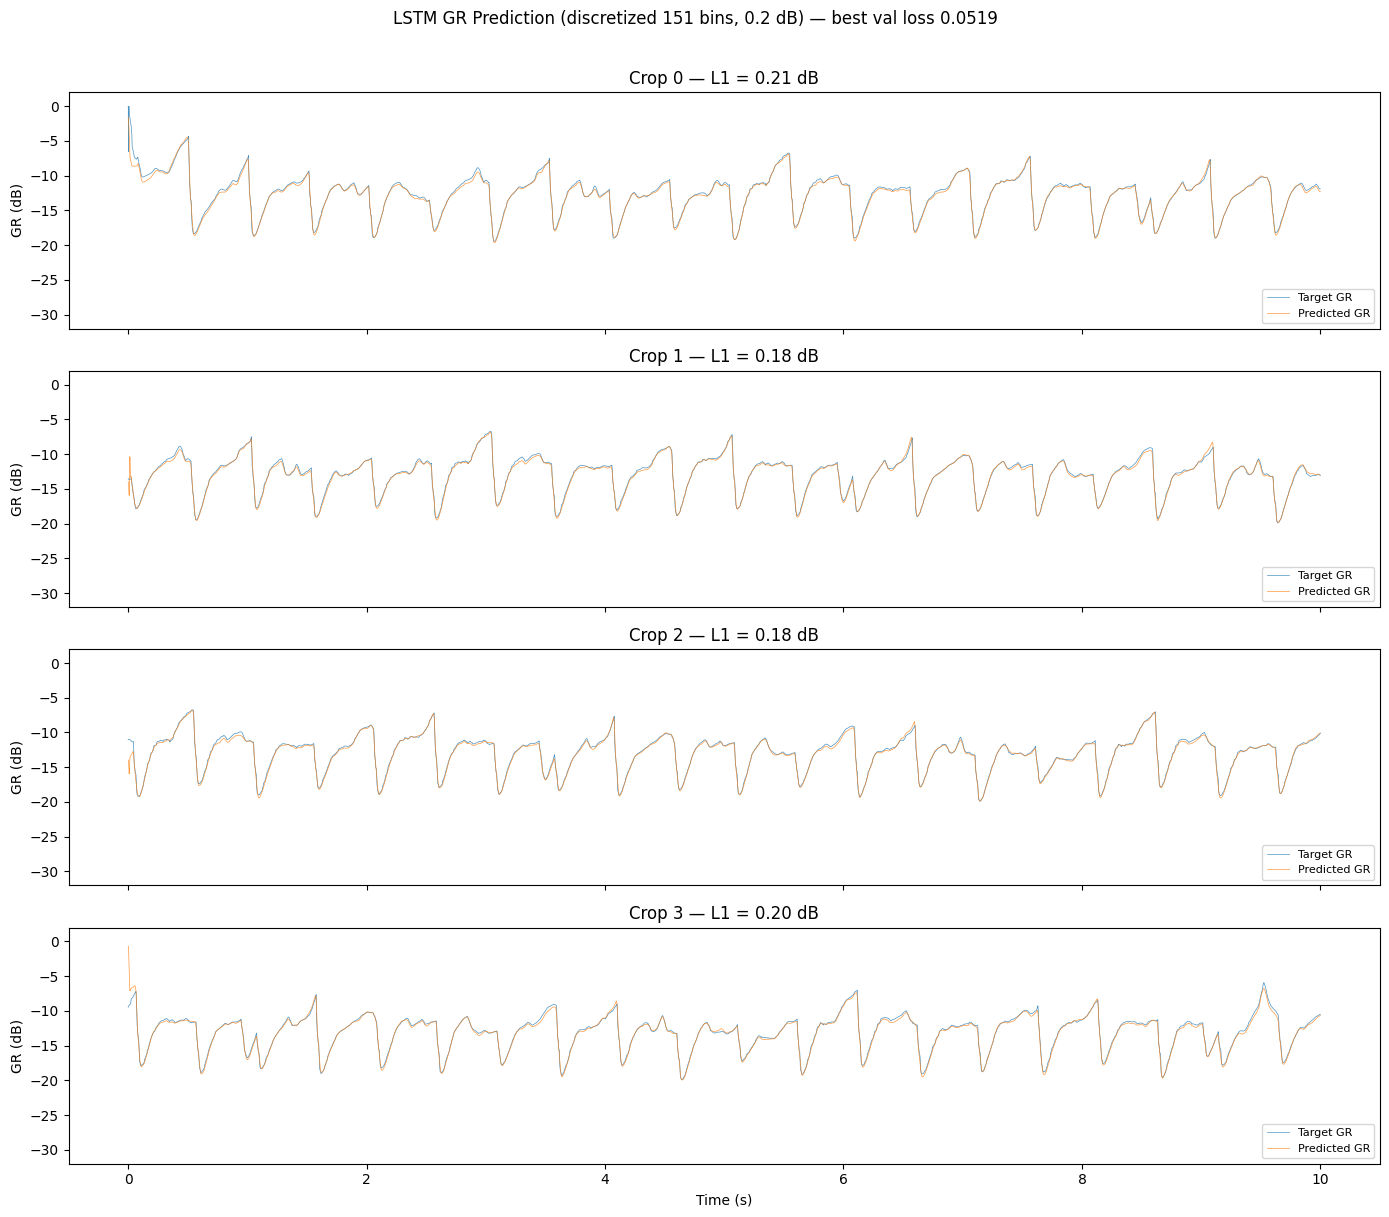

In [ ]:
# ── 8. Evaluate: plot predicted vs target GR ─────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Load best checkpoint weights
ckpt = torch.load(best_cb.best_model_path, map_location="cuda", weights_only=False)
system.load_state_dict(ckpt["state_dict"])
system.eval().cuda()
print(f"Loaded best checkpoint: {best_cb.best_model_path}")

# Run on a few validation crops
dm.setup()
val_dl = dm.val_dataloader()
batch = next(iter(val_dl))
dry, gr_db = batch[0].cuda(), batch[1].cuda()

with torch.no_grad(), torch.amp.autocast(device_type="cuda"):
    logits = system(dry)
    gr_pred_db = system.model.to_db(logits, T=dry.shape[-1])
    gr_target_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)

gr_pred_db = gr_pred_db.cpu().numpy()
gr_target_db = gr_target_db.cpu().numpy()

n_plots = min(4, dry.shape[0])
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

t = np.arange(gr_pred_db.shape[-1]) / SAMPLE_RATE

for i, ax in enumerate(axes):
    ax.plot(t, gr_target_db[i, 0], label="Target GR", alpha=0.8, linewidth=0.5)
    ax.plot(t, gr_pred_db[i, 0], label="Predicted GR", alpha=0.8, linewidth=0.5)
    l1_db = np.mean(np.abs(gr_pred_db[i, 0] - gr_target_db[i, 0]))
    ax.set_ylabel("GR (dB)")
    ax.set_title(f"Crop {i} — L1 = {l1_db:.2f} dB")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(GR_DB_MIN - 2, 2)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"LSTM GR Prediction (discretized {GR_NUM_BINS} bins, {GR_BIN_RESOLUTION} dB) "
    f"— best val loss {best_cb.best_model_score:.4f}",
    y=1.01,
)
fig.tight_layout()

plot_path = os.path.join(RUN_DIR, "eval_gr_comparison.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot → {plot_path}") 
plt.show()